In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyranges as pr
import pyBigWig
import re
from matplotlib.cm import get_cmap
import matplotlib.colors as mcolors


In [2]:
def average_sample_repeats(merged_pyranges):
    df = merged_pyranges.copy()

    sample_groups = {}
    for col in df.columns[7:]:  
        base_name = re.sub(r'_\d+$', '', col)
        if base_name not in sample_groups:
            sample_groups[base_name] = []
        sample_groups[base_name].append(col)

    averaged_df = df[['Chromosome', 'Start', 'End', 'Cluster','peak_center', 'start_300', 'end_300']].copy()
    for base_name, cols in sample_groups.items():
        averaged_df[base_name + "_avg"] = df[cols].mean(axis=1)
    return pr.PyRanges(averaged_df)

In [3]:
def plot_density(df, combinations):

    base = get_cmap('viridis')
    colors = base(np.linspace(0.1, 1, 256)) 
    colors[0] = [1, 1, 1, 1]
    white_viridis = mcolors.ListedColormap(colors)    

    fig, axes = plt.subplots(1, len(combinations), figsize=(5 * len(combinations), 5), facecolor='white')

    if len(combinations) == 1:
        axes = [axes]

    for ax, (x_col, y_col) in zip(axes, combinations):
        data = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        h = ax.hist2d(
            data[x_col], data[y_col],
            bins=150,
            cmap=white_viridis,
            vmin=0,
            vmax = 80,
            rasterized=True
        )
        
        x_min, x_max = data[x_col].min(), data[x_col].max()
        y_min, y_max = data[y_col].min(), data[y_col].max()
        
        x_pad = (x_max - x_min) * 0.05
        y_pad = (y_max - y_min) * 0.05
        
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

    
        cbar = plt.colorbar(h[3], ax=ax)

        ax.set_facecolor("white")
        ax.set_xlabel(x_col, fontsize=14)
        ax.set_ylabel(y_col, fontsize=14)

    plt.tight_layout()
    return fig, axes

In [4]:
def extract_signal(bigwig_file, peaks, flank=1000):
    bw = pyBigWig.open(bigwig_file)
    signals = []

    for _, row in peaks.iterrows():
        chrom, center = row["Chromosome"], row["peak_center"]
        start, end = center - flank, center + flank

        if chrom not in bw.chroms():
            print(f"Skipping {chrom}: not found in BigWig.")
            signals.append(np.full((2 * flank,), np.nan))
            continue
        
        chrom_length = bw.chroms(chrom)
        if start < 0 or end > chrom_length:
            print(f"Skipping {chrom} {start}-{end}: out of bounds.")
            signals.append(np.full((2 * flank,), np.nan))
            continue

        try:
            signal = np.nan_to_num(bw.values(chrom, start, end))
            signals.append(signal)
        except Exception as e:
            print(f"Error extracting {chrom} {start}-{end}: {e}")
            signals.append(np.full((2 * flank,), np.nan))

    bw.close()
    return np.array(signals, dtype=np.float32)

In [5]:
def plot_signal_heatmaps(samples, bw_files, dominated_peaks, combined_df, 
                                    vmax_values={}, sample_colors={}, sample_labels={}, save_as=None):

    colormap_options = {
        "ar1": sns.blend_palette(["white", "#285E57"], as_cmap=True),
        "ar2": sns.blend_palette(["white", "#71C9BE"], as_cmap=True),
        "gr1": sns.blend_palette(["white", "#185F91"], as_cmap=True),
        "gr2": sns.blend_palette(["white", "#29AFD8"], as_cmap=True),
        "pr1": sns.blend_palette(["white", "#5A4B91"], as_cmap=True),
        "pr2": sns.blend_palette(["white", "#9A4198"], as_cmap=True)
    }

    # Extract signal
    signals = {key: extract_signal(bw_files[key], combined_df) for key in samples}

    sorted_indices = {}
    for key in samples:
        peak_lengths = [len(df) for df in dominated_peaks[key]]
        sections = np.split(np.arange(sum(peak_lengths)), np.cumsum(peak_lengths[:-1]))
        sorted_sections = [np.argsort(-signals[key][section].mean(axis=1)) for section in sections]
        sorted_indices[key] = np.concatenate(
            [sorted_sections[i] + sum(peak_lengths[:i]) for i in range(len(sections))]
        )

    num_samples = len(samples)

    fig, axes = plt.subplots(
        3, num_samples, figsize=(num_samples * 3.5, 12),
        gridspec_kw={"height_ratios": [2, 10, 0.3]}
    )

    section_colors = ["#91B591", "#6DB1AB", "#195E90"]  # AR, GR, PR section colors

    for i, sample in enumerate(samples):
        color_key = sample_colors[sample]
        cmap = colormap_options[color_key]
        vmax = vmax_values.get(sample, None)
        
        # Average Signal
        ax_signal = axes[0, i]
        peak_lengths = [len(df) for df in dominated_peaks[sample]]

        has_valid_section = False
        max_y = 0

        for j, df in enumerate(dominated_peaks[sample]):
            if df.empty:
                print(f"Skipping empty section {j+1} for sample {sample}")
                continue

            section_signal = extract_signal(bw_files[sample], df)
            if section_signal.size == 0:
                print(f"Skipping section {j+1} for sample {sample} (no extracted signal)")
                continue

            mean_signal = np.nanmean(section_signal, axis=0)
            x = np.arange(-1000, 1000)

            ax_signal.plot(x, mean_signal, label=f"Section {j + 1}", color=section_colors[j], linewidth=1.5)
            max_y = max(max_y, np.nanmax(mean_signal))
            has_valid_section = True

        ax_signal.axvline(0, color="black", linestyle="--", linewidth=1)
        ax_signal.set_xticks([-1000, 0, 1000])
        ax_signal.set_xticklabels(["-1000", "0", "1000"])

        if has_valid_section:
            ymax = np.ceil(max_y) if np.isfinite(max_y) else 1
            ax_signal.set_ylim(0, ymax)

            num_ticks = min(5, int(ymax) + 1)
            yticks = np.linspace(0, ymax, num_ticks) if ymax > 0 else [0]
            ax_signal.set_yticks(yticks)
            ax_signal.set_yticklabels([f"{y:.0f}" for y in yticks], fontsize=8)

            ax_signal.set_title(sample_labels.get(sample, sample), fontsize=12)
            ax_signal.legend(fontsize=8)
        else:
            ax_signal.set_xticks([])
            ax_signal.set_yticks([])
            ax_signal.set_title(sample_labels.get(sample, sample), fontsize=12)

       # Heatmap
        ax_heatmap = axes[1, i]
        im = ax_heatmap.imshow(signals[sample][sorted_indices[sample]], aspect="auto", cmap=cmap, vmax=vmax)

        ax_heatmap.set_yticks([])
        ax_heatmap.set_xticks([0, signals[sample].shape[1] // 2, signals[sample].shape[1] - 1])
        ax_heatmap.set_xticklabels(["-1000", "0", "1000"], fontsize=10)

        for peak_len in np.cumsum(peak_lengths[:-1]):
            ax_heatmap.axhline(y=peak_len, color="black", linestyle="dashed", linewidth=1)

        # Colorbar
        cbar_ax = axes[2, i]
        cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", fraction=0.05, pad=0.1)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(size=0, labelsize=8)

    plt.tight_layout(h_pad=2)

    if save_as:
        plt.savefig(save_as, dpi=300, bbox_inches='tight')

    plt.show()

In [6]:
# For HepG2 df
def add_peak_center_and_range(df):
    df = df.copy()  
    df.insert(3, "peak_center", ((df["Start"] + df["End"]) / 2).astype(int))
    df.insert(4, "start_300", df["peak_center"] - 300)
    df.insert(5, "end_300", df["peak_center"] + 300)

    return df


In [7]:
# For HepG2
def average_sample_repeats_new(df):
    df = df.copy()

    signal_columns = df.columns[12:]

    sample_groups = {}
    for col in signal_columns:
        base_name = re.sub(r'\d+$', '', col)
        if base_name not in sample_groups:
            sample_groups[base_name] = []
        sample_groups[base_name].append(col)

    # Averaging
    averaged_df = df.iloc[:, :12].copy() 
    for base_name, cols in sample_groups.items():
        averaged_df[f"{base_name}_avg"] = df[cols].mean(axis=1)

    return pr.PyRanges(averaged_df)


# NMuMG

In [8]:
NMu_signal = pd.read_parquet('data/NMuMG_Clustered_Peaks.parquet')

In [9]:
NMu_Pcorr = NMu_signal.iloc[: , 7:].corr(method="pearson")

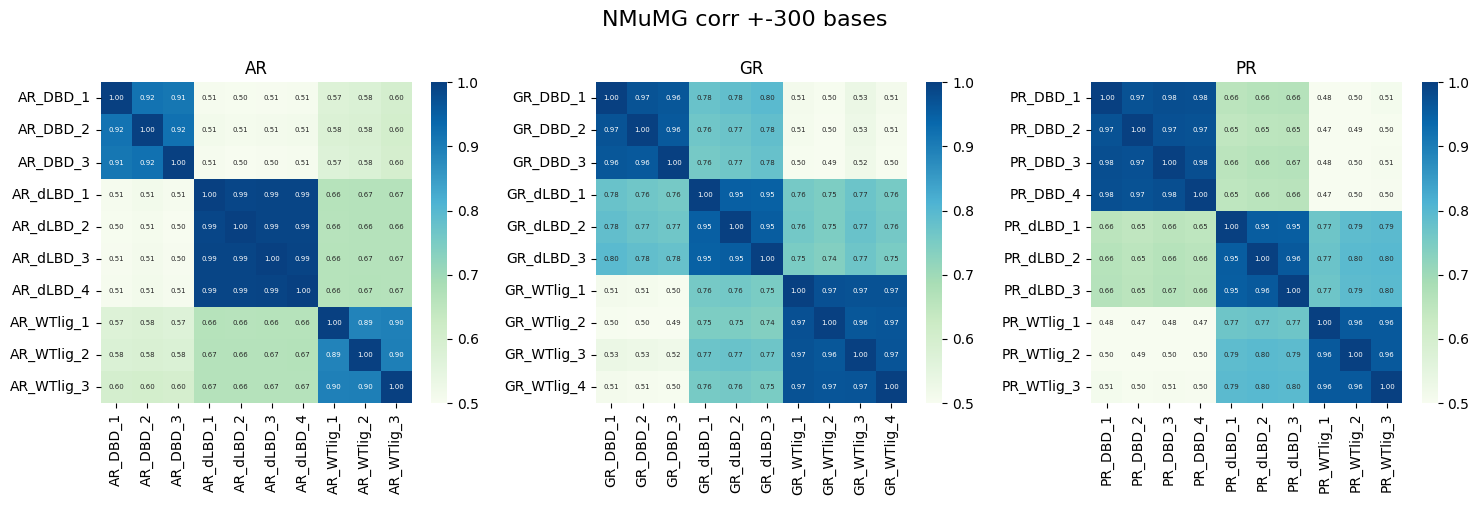

In [10]:
def plot_correlation_heatmaps(AR, GR, PR): 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.heatmap(AR, cmap='GnBu', vmin=.5, vmax=1, ax=axes[0], annot=True, annot_kws={"size": 5}, fmt=".2f") 
    axes[0].set_title('AR')
    axes[0].set_rasterized(True) 

    sns.heatmap(GR, cmap='GnBu', vmin=.5, vmax=1, ax=axes[1], annot=True, annot_kws={"size": 5}, fmt=".2f") 
    axes[1].set_title('GR')
    axes[1].set_rasterized(True) 

    sns.heatmap(PR, cmap='GnBu', vmin=.5, vmax=1, ax=axes[2], annot=True, annot_kws={"size": 5}, fmt=".2f") 
    axes[2].set_title('PR')
    axes[2].set_rasterized(True) 

    fig.suptitle('NMuMG corr +-300 bases', fontsize=16, y=1)

    plt.tight_layout()

plot_correlation_heatmaps(NMu_Pcorr.filter(regex=('AR'), axis=1).filter(regex=('AR'), axis=0),
                          NMu_Pcorr.filter(regex='GR', axis=1).filter(regex='GR', axis=0),
                         NMu_Pcorr.filter(regex='PR', axis=1).filter(regex='PR', axis=0)
                         )

plt.show()


In [11]:
NMu_av = average_sample_repeats(NMu_signal)

In [12]:
n_combinations = [
    ('AR_dLBD_avg', 'AR_DBD_avg'), ('GR_dLBD_avg', 'GR_DBD_avg'), ('PR_dLBD_avg', 'PR_DBD_avg')
]

In [13]:
# removing outliers
NMu_signal_p998 = NMu_signal.copy()
NMu_signal_p998.iloc[:, 7:] = NMu_signal_p998.iloc[:, 7:][NMu_signal_p998.iloc[:, 7:].le(NMu_signal_p998.iloc[:, 7:].quantile(0.998))]

In [14]:
NMu_av_998 = average_sample_repeats(NMu_signal_p998)

/tmp/ipykernel_1549626/3518735490.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = get_cmap('viridis')


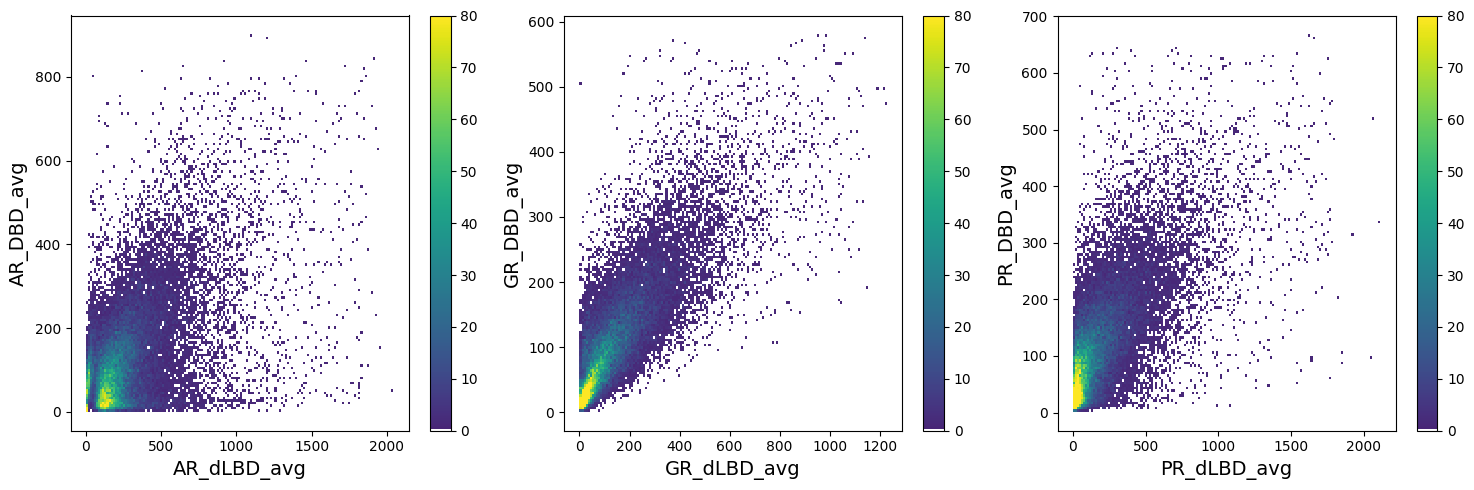

In [15]:
fig, axes = plot_density(NMu_av_998.df, n_combinations)
plt.show()

In [16]:
# z score (data - data.mean()) / data.std
NMu_zscore = NMu_av.df.copy()
NMu_zscore.iloc[:, 7:] = (NMu_zscore.iloc[:, 7:] - NMu_zscore.iloc[:, 7:].mean()) / NMu_zscore.iloc[:, 7:].std()

In [17]:
dlbd_ar_dominated = NMu_zscore[(NMu_zscore['AR_dLBD_avg'] >= 2.5) & (NMu_zscore['AR_DBD_avg'] <= 1.5)] 
dlbd_gr_dominated = NMu_zscore[(NMu_zscore['GR_dLBD_avg'] >= 2.5) & (NMu_zscore['GR_DBD_avg'] <= 1.5)] 
dlbd_pr_dominated = NMu_zscore[(NMu_zscore['PR_dLBD_avg'] >= 2.5) & (NMu_zscore['PR_DBD_avg'] <= 1.5)] 

dbd_ar_dominated = NMu_zscore[(NMu_zscore['AR_DBD_avg'] >= 2.5) & (NMu_zscore['AR_dLBD_avg'] <= 1.5)] 
dbd_gr_dominated = NMu_zscore[(NMu_zscore['GR_DBD_avg'] >= 2.5) & (NMu_zscore['GR_dLBD_avg'] <= 1.5)] 
dbd_pr_dominated = NMu_zscore[(NMu_zscore['PR_DBD_avg'] >= 2.5) & (NMu_zscore['PR_dLBD_avg'] <= 1.5)] 

In [18]:
n_ar_combined_df = pd.concat([dlbd_ar_dominated, dbd_ar_dominated])
n_gr_combined_df = pd.concat([dlbd_gr_dominated, dbd_gr_dominated])
n_pr_combined_df = pd.concat([dlbd_pr_dominated, dbd_pr_dominated])

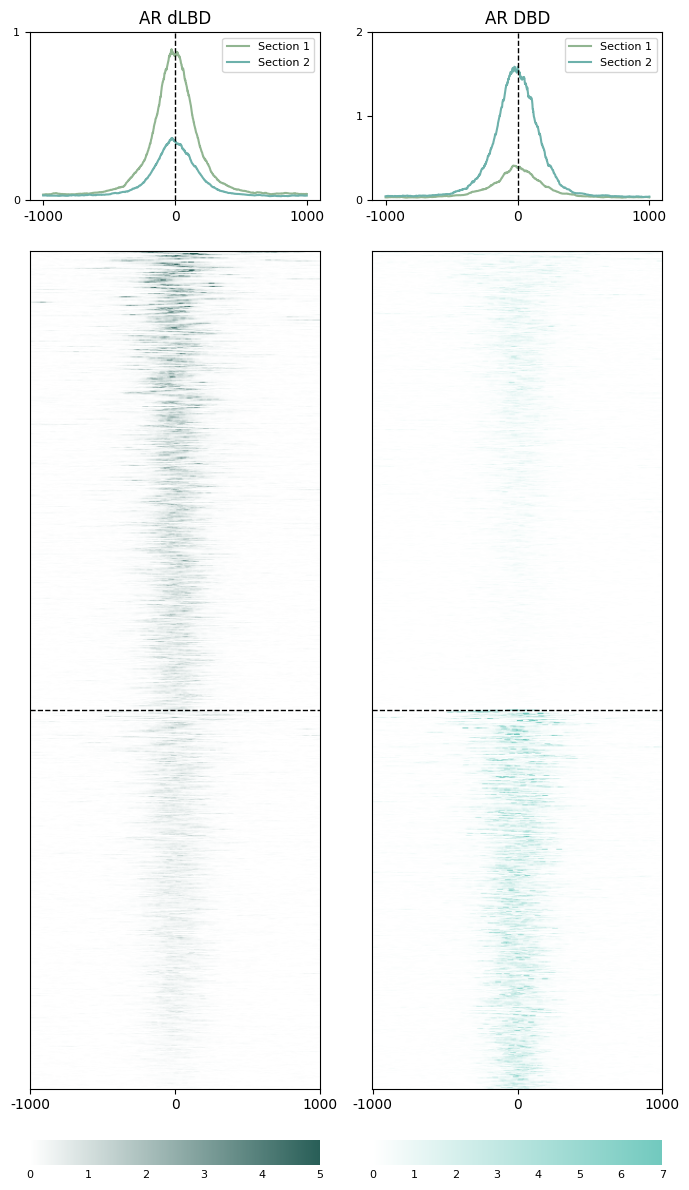

In [19]:
samples = ['AR dLBD', 'AR DBD']
bw_files = {
    "AR dLBD": 'data/AverageBw/NMuMG_mAR_dLBD_averaged.bw',
    "AR DBD": 'data/AverageBw/mAR_DBD_averaged.bw',
}
dominated_peaks = {
    'AR dLBD': [dlbd_ar_dominated,dbd_ar_dominated],
    'AR DBD': [dlbd_ar_dominated,dbd_ar_dominated]
}

sample_colors = {
    'AR dLBD': 'ar1', 
    'AR DBD': 'ar2'
}

vmax_values = {
    "AR dLBD": 5,
    "AR DBD": 7,
}

sample_labels = {
    "AR dLBD": "AR dLBD",
    "AR DBD": "AR DBD",
}

plot_signal_heatmaps(
    samples,
    bw_files,
    dominated_peaks,
    n_ar_combined_df,
    vmax_values,
    sample_colors,
    sample_labels,
)


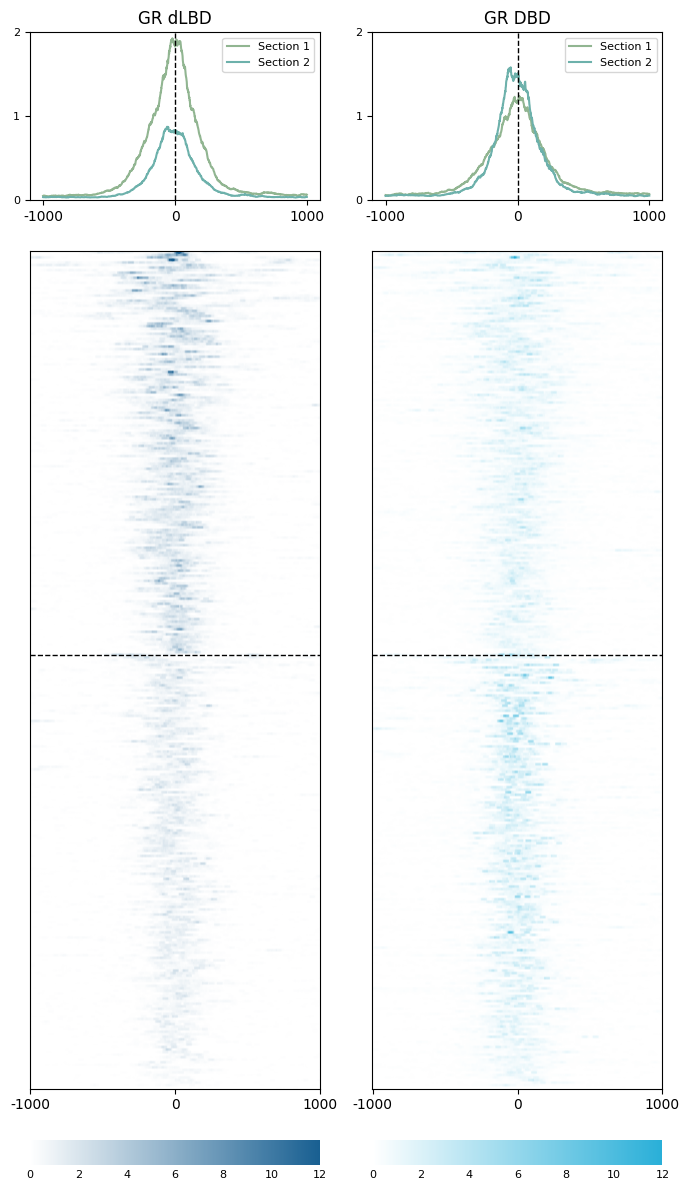

In [22]:
samples = ['GR dLBD', 'GR DBD']
bw_files = {
    "GR dLBD": 'data/AverageBw/hGR_dLBD_averaged.bw',
    "GR DBD": 'data/AverageBw/hGR_DBD_averaged.bw'
}
dominated_peaks = {
    'GR dLBD': [dlbd_gr_dominated,dbd_gr_dominated],
    'GR DBD': [dlbd_gr_dominated,dbd_gr_dominated]
}

sample_colors = {
    'GR dLBD': 'gr1', 
    'GR DBD': 'gr2'
}

vmax_values = {
    "GR dLBD": 12, 
    "GR DBD": 12,
}

sample_labels = {
    "GR dLBD": "GR dLBD",
    "GR DBD": "GR DBD",
}

# Call the function
plot_signal_heatmaps(
    samples,
    bw_files,
    dominated_peaks,
    n_gr_combined_df,
    vmax_values,
    sample_colors,
    sample_labels,
)

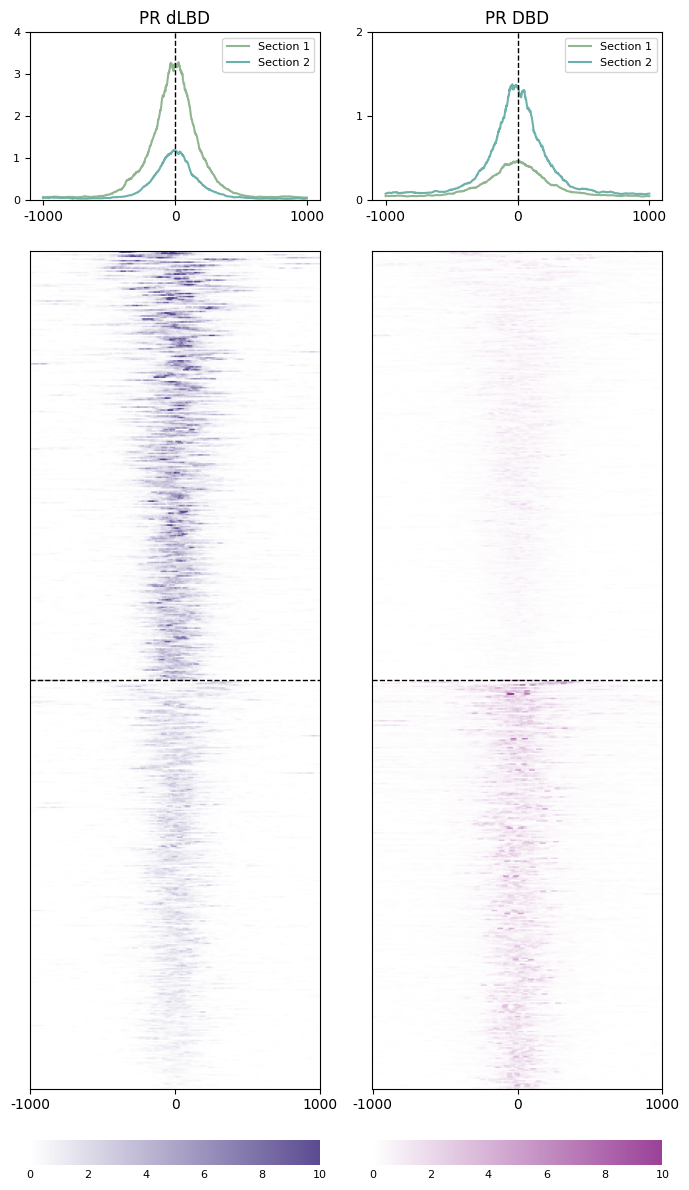

In [24]:
samples = ['PR dLBD', 'PR DBD']
bw_files = {
    "PR dLBD": 'data/AverageBw/hPR_del_LBD_averaged.bw',
    "PR DBD": 'data/AverageBw/NMuMG_hPR_DBD_averaged.bw'
}

dominated_peaks = {
    'PR dLBD': [dlbd_pr_dominated,dbd_pr_dominated],
    'PR DBD': [dlbd_pr_dominated,dbd_pr_dominated]
}

sample_colors = {
    'PR dLBD': 'pr1', 
    'PR DBD': 'pr2'
}

vmax_values = {
    "PR dLBD": 10, 
    "PR DBD": 10,
}

sample_labels = {
    "PR dLBD": "PR dLBD",
    "PR DBD": "PR DBD",
}

plot_signal_heatmaps(
    samples,
    bw_files,
    dominated_peaks,
    n_pr_combined_df,
    vmax_values,
    sample_colors,
    sample_labels,
)




# HepG2

In [20]:
Hep_signal = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/hepg2_clustered_peak_wmotifs_wsignals_repeats.parquet')
Hep_signal = add_peak_center_and_range(Hep_signal)

In [21]:
Hep_signal = Hep_signal.reindex(columns=['Chromosome', 'Start', 'End', 'peak_center', 'start_300', 'end_300','Column',
                                         'NR_hepg2_cluster', 'NR_hepg2_cluster','FOX_hepg2_cluster', 'AP1_hepg2_cluster', 'pmiddle',
                                         'hepg2_ar_dbd1','hepg2_ar_dbd2',
                                         'hepg2_ar_dlbd1', 'hepg2_ar_dlbd2','hepg2_ar_dlbd3',
                                         'hepg2_ar_wt_lig1', 'hepg2_ar_wt_lig2','hepg2_ar_wt_lig3',
                                         'hepg2_gr_dbd1', 'hepg2_gr_dbd2', 'hepg2_gr_dbd3',
                                         'hepg2_gr_dlbd1','hepg2_gr_dlbd2', 'hepg2_gr_dlbd3',
                                         'hepg2_gr_wt__lig1', 'hepg2_gr_wt__lig2',
                                         'hepg2_pr_dbd1', 'hepg2_pr_dbd2',
                                         'hepg2_pr_dlbd1', 'hepg2_pr_dlbd2', 'hepg2_pr_dlbd3',
                                         'hepg2_pr_wt_lig1', 'hepg2_pr_wt_lig2', 'hepg2_pr_wt_lig3'
                                         ])

In [22]:
Hep_Pcorr = Hep_signal.iloc[: , 12:].corr(method="pearson")

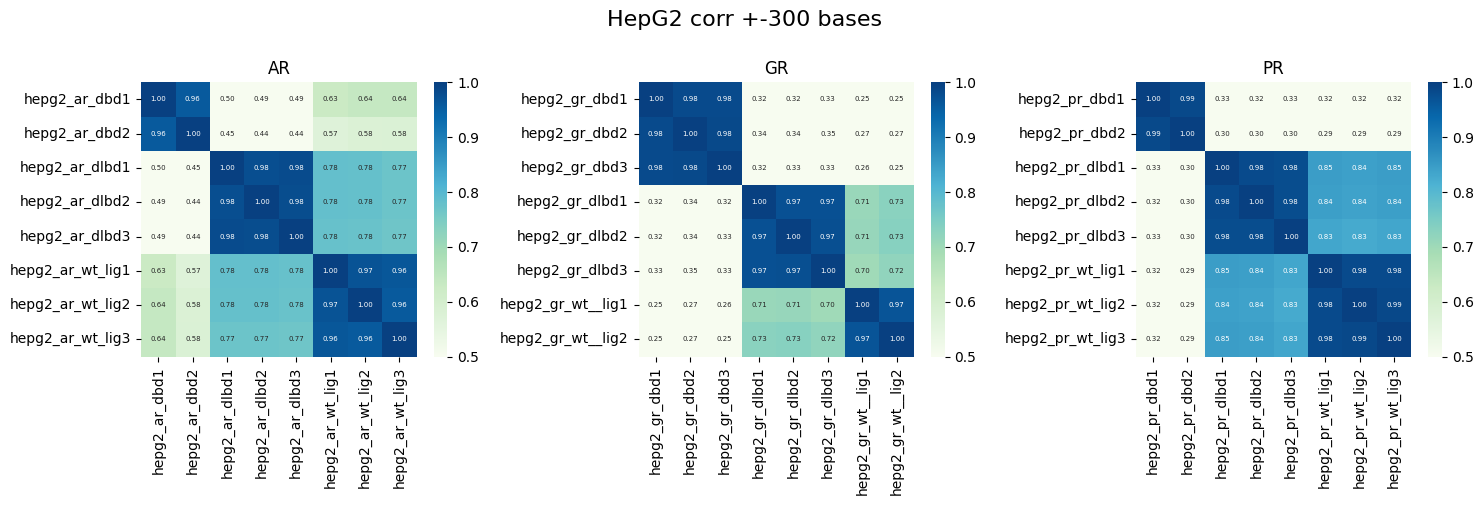

In [23]:
def plot_correlation_heatmaps(AR, GR, PR): 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.heatmap(AR, cmap='GnBu', vmin=.5, vmax=1, ax=axes[0], annot=True, annot_kws={"size": 5}, fmt=".2f") 
    axes[0].set_title('AR')
    axes[0].set_rasterized(True) 

    sns.heatmap(GR, cmap='GnBu', vmin=.5, vmax=1, ax=axes[1], annot=True, annot_kws={"size": 5}, fmt=".2f") 
    axes[1].set_title('GR')
    axes[1].set_rasterized(True) 

    sns.heatmap(PR, cmap='GnBu', vmin=.5, vmax=1, ax=axes[2], annot=True, annot_kws={"size": 5}, fmt=".2f") 
    axes[2].set_title('PR')
    axes[2].set_rasterized(True) 

    fig.suptitle('HepG2 corr +-300 bases', fontsize=16, y=1)

    plt.tight_layout()

plot_correlation_heatmaps(Hep_Pcorr.filter(regex=('ar'), axis=1).filter(regex=('ar'), axis=0),
                          Hep_Pcorr.filter(regex='gr', axis=1).filter(regex='gr', axis=0),
                         Hep_Pcorr.filter(regex='pr', axis=1).filter(regex='pr', axis=0)
                         )

plt.show()


In [28]:
Hep_av = average_sample_repeats_new(Hep_signal)

In [29]:
h_combinations = [
    ('hepg2_ar_dlbd_avg', 'hepg2_ar_dbd_avg'), ('hepg2_gr_dlbd_avg', 'hepg2_gr_dbd_avg'), ('hepg2_pr_dlbd_avg', 'hepg2_pr_dbd_avg')
]

In [30]:
Hep_signal_p998 = Hep_signal.copy()
Hep_signal_p998.iloc[:, 12:] = Hep_signal_p998.iloc[:, 12:][Hep_signal_p998.iloc[:, 12:].le(Hep_signal_p998.iloc[:, 12:].quantile(0.998))]

In [31]:
Hep_av_998 = average_sample_repeats_new(Hep_signal_p998)

/tmp/ipykernel_1549626/3518735490.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = get_cmap('viridis')


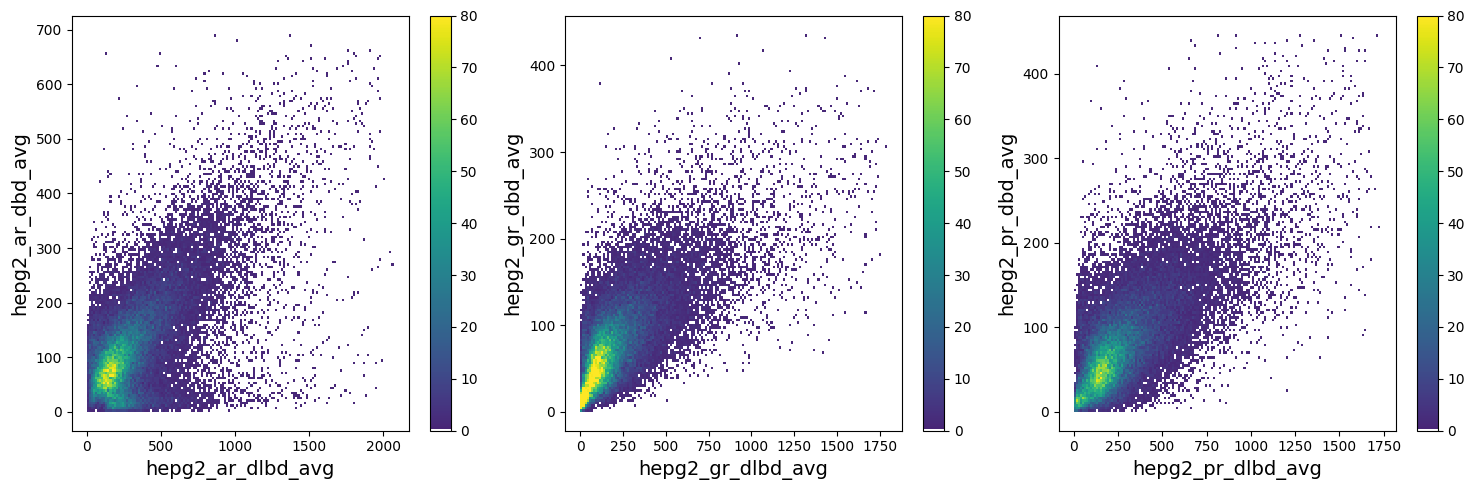

In [32]:
fig, axes = plot_density(Hep_av_998.df, h_combinations)
plt.show()